# TMD-07: Complete Evaluation Suite
## Teaching Machines to Dream · Engineer's Handbook Series

**Authors:** Aimal Khan · Hamza Raziq Khan  
**Handbook:** Teaching Machines to Dream: A Practical Engineer's Handbook on Synthetic Data

---

This is the final notebook in the TMD series and the companion to
**Chapter 8: Evaluating Synthetic Data Quality** of the handbook.

### What This Notebook Does

Most tutorials evaluate synthetic data with one or two metrics and call it done.
That is not enough. A synthetic dataset can pass a statistical test and still
be useless for machine learning. It can have a great TSTR score and still
expose real individuals through membership inference.

This notebook runs the complete evaluation stack from the handbook in one place:

```
Layer 1: Statistical   KS test, Jensen-Shannon divergence, correlation diff
Layer 2: ML Utility    TSTR, TRTS detector score
Layer 3: Visual        UMAP embedding overlap
Layer 4: Privacy       Membership inference attack simulation
```

### What You Will Learn

- Run a full statistical fidelity evaluation with KS test and JSD
- Measure ML utility with TSTR and TRTS
- Visualize real vs synthetic embedding overlap with UMAP
- Simulate a membership inference attack
- Produce a single final evaluation report card
- Understand what each metric means and when it matters

### No GPU Required. 

---

## Dataset

This notebook uses the **Adult Census Income** dataset.

To add it:
1. Click **Add Data** on the right panel
2. Search for: `adult census income`
3. Add the dataset by **uciml**
4. File at `/kaggle/input/adult-census-income/adult.csv`

**Exact dataset name:** `uciml/adult-census-income`

---
## 1. Setup

In [1]:
!pip install sdv umap-learn -q
print("Installation complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 908.1 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 816.0 kB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 968.2 kB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 1.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 1.4 MB/s eta 0:00:0000:0100:01
Installation complete.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import umap
import warnings
from scipy import stats
from scipy.spatial.distance import jensenshannon

from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import SingleTableMetadata
from sdv.evaluation.single_table import evaluate_quality

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor']   = '#161b22'
plt.rcParams['axes.edgecolor']   = '#30363d'
plt.rcParams['axes.labelcolor']  = '#c9d1d9'
plt.rcParams['xtick.color']      = '#8b949e'
plt.rcParams['ytick.color']      = '#8b949e'
plt.rcParams['text.color']       = '#c9d1d9'
plt.rcParams['grid.color']       = '#21262d'
plt.rcParams['grid.linestyle']   = ':'

REAL_COLOR  = '#58a6ff'
SYNTH_COLOR = '#f85149'
PASS_COLOR  = '#3fb950'
FAIL_COLOR  = '#f85149'
WARN_COLOR  = '#ffa657'

print("All imports complete.")

2026-05-09 19:20:48.964429: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778354449.251540      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778354449.334429      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778354450.072330      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778354450.072387      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778354450.072390      57 computation_placer.cc:177] computation placer alr

All imports complete.


---
## 2. Load Data and Generate Synthetic Version

In [3]:
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/adult-census-income/adult.csv')
df.columns = df.columns.str.strip()
df = df.replace('?', np.nan).dropna().reset_index(drop=True)

real_data = df.sample(n=3000, random_state=42).reset_index(drop=True)

print("Fitting synthesizer...")
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(real_data)

synth = GaussianCopulaSynthesizer(metadata)
synth.fit(real_data)
synthetic_data = synth.sample(num_rows=3000)

print(f"Real data:      {real_data.shape}")
print(f"Synthetic data: {synthetic_data.shape}")

Fitting synthesizer...
Real data:      (3000, 15)
Synthetic data: (3000, 15)


---
## Layer 1: Statistical Fidelity

Statistical tests measure whether the synthetic data matches the real
data column by column. These are the cheapest and fastest checks.
Run them first. If they fail, there is no point running anything else.

In [4]:
num_cols = real_data.select_dtypes('number').columns.tolist()

ks_results = []
for col in num_cols:
    ks_stat, ks_pval = stats.ks_2samp(
        real_data[col].dropna(),
        synthetic_data[col].dropna())

    r_hist, edges = np.histogram(
        real_data[col].dropna(), bins=50, density=True)
    s_hist, _ = np.histogram(
        synthetic_data[col].dropna(), bins=edges, density=True)
    jsd = jensenshannon(r_hist + 1e-8, s_hist + 1e-8)

    ks_results.append({
        'column':  col,
        'ks_stat': round(ks_stat, 4),
        'ks_pval': round(ks_pval, 4),
        'jsd':     round(jsd, 4),
        'pass':    ks_pval > 0.05 and jsd < 0.2
    })

ks_df = pd.DataFrame(ks_results)
print("Statistical Fidelity Results:")
print(ks_df.to_string(index=False))
print(f"\nColumns passing: {ks_df['pass'].sum()} / {len(ks_df)}")

Statistical Fidelity Results:
        column  ks_stat  ks_pval    jsd  pass
           age   0.0383   0.0243 0.0753 False
        fnlwgt   0.0873   0.0000 0.1509 False
 education.num   0.1463   0.0000 0.2950 False
  capital.gain   0.8907   0.0000 0.5136 False
  capital.loss   0.3520   0.0000 0.1417 False
hours.per.week   0.2277   0.0000 0.4594 False

Columns passing: 0 / 6


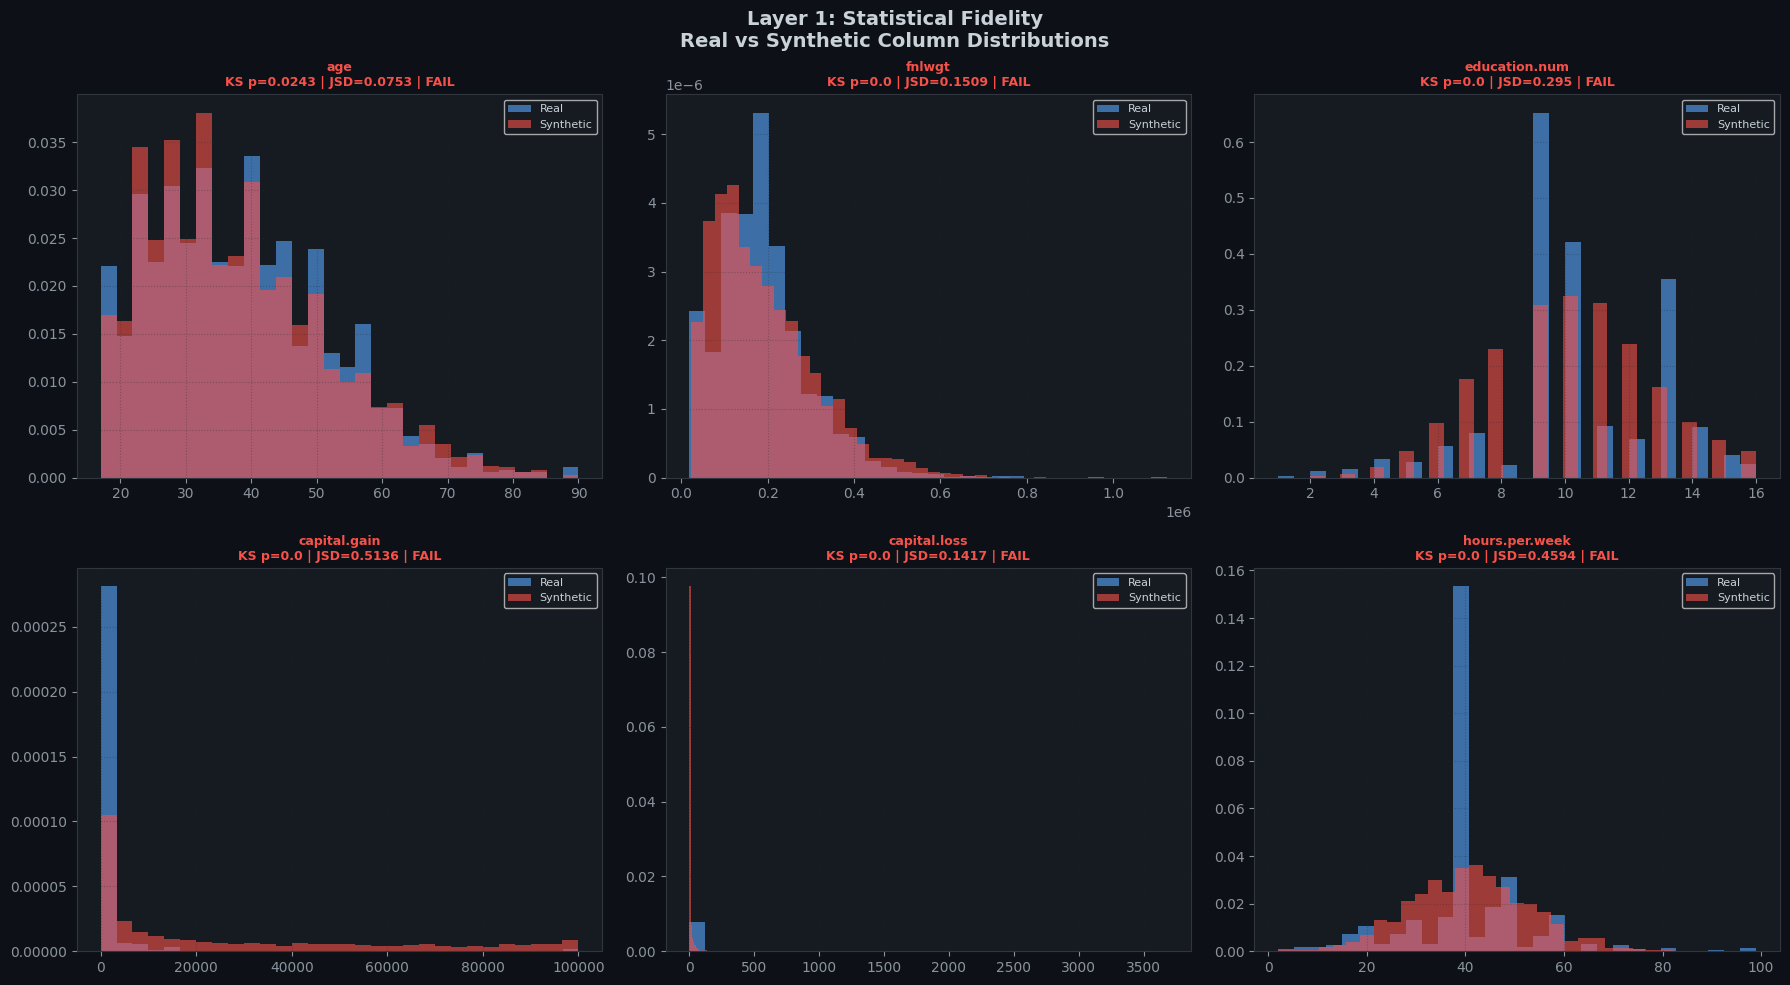

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Layer 1: Statistical Fidelity\nReal vs Synthetic Column Distributions',
             fontsize=14, fontweight='bold', color='#c9d1d9')

for ax, row in zip(axes.flat, ks_results[:6]):
    col   = row['column']
    color = PASS_COLOR if row['pass'] else FAIL_COLOR
    ax.hist(real_data[col].dropna(), bins=30,
            color=REAL_COLOR, alpha=0.6,
            label='Real', density=True)
    ax.hist(synthetic_data[col].dropna(), bins=30,
            color=SYNTH_COLOR, alpha=0.6,
            label='Synthetic', density=True)
    status = 'PASS' if row['pass'] else 'FAIL'
    ax.set_title(
        f"{col}\nKS p={row['ks_pval']} | JSD={row['jsd']} | {status}",
        fontsize=9, color=color, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('layer1_statistical.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

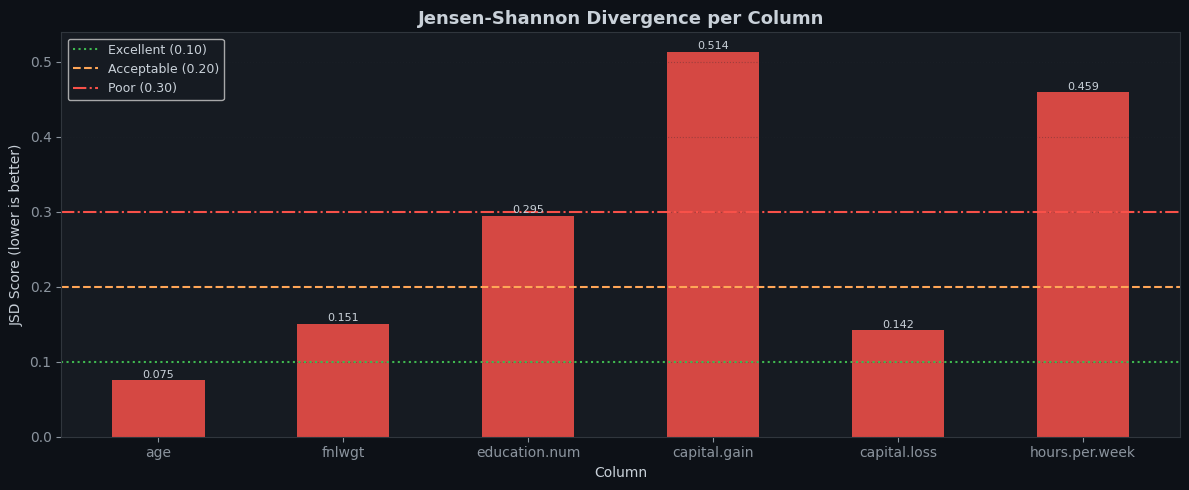

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = [PASS_COLOR if p else FAIL_COLOR
          for p in ks_df['pass']]
bars = ax.bar(ks_df['column'], ks_df['jsd'],
              color=colors, alpha=0.85, width=0.5)
ax.axhline(y=0.1, color=PASS_COLOR, linestyle=':',
           linewidth=1.5, label='Excellent (0.10)')
ax.axhline(y=0.2, color=WARN_COLOR, linestyle='--',
           linewidth=1.5, label='Acceptable (0.20)')
ax.axhline(y=0.3, color=FAIL_COLOR, linestyle='-.',
           linewidth=1.5, label='Poor (0.30)')
ax.set_title('Jensen-Shannon Divergence per Column',
             fontsize=13, fontweight='bold')
ax.set_ylabel('JSD Score (lower is better)')
ax.set_xlabel('Column')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, ks_df['jsd']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{val:.3f}', ha='center',
            fontsize=8, color='#c9d1d9')
plt.tight_layout()
plt.savefig('jsd_scores.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
## Layer 2: ML Utility

Statistical similarity does not guarantee ML utility. A dataset can
pass every statistical test and still fail to train a useful model.
The TSTR and TRTS scores measure what actually matters.

In [7]:
target = 'income'

def encode_df(df):
    d  = df.copy()
    le = LabelEncoder()
    for col in d.select_dtypes('object').columns:
        d[col] = le.fit_transform(d[col].astype(str))
    return d

real_enc  = encode_df(real_data)
synth_enc = encode_df(synthetic_data)

X_real = real_enc.drop(columns=[target])
y_real = real_enc[target]
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42)

# Baseline: Train on Real, Test on Real
clf_real = GradientBoostingClassifier(
    n_estimators=100, random_state=42)
clf_real.fit(X_tr_r, y_tr_r)
f1_real_baseline = f1_score(
    y_te_r, clf_real.predict(X_te_r), average='weighted')

# TSTR: Train on Synthetic, Test on Real
X_synth = synth_enc.drop(columns=[target])
y_synth = synth_enc[target]
clf_synth = GradientBoostingClassifier(
    n_estimators=100, random_state=42)
clf_synth.fit(X_synth, y_synth)
f1_tstr = f1_score(
    y_te_r, clf_synth.predict(X_te_r), average='weighted')
tstr_ratio = f1_tstr / f1_real_baseline

print(f"Real-trained F1 (baseline): {f1_real_baseline:.4f}")
print(f"TSTR F1:                    {f1_tstr:.4f}")
print(f"TSTR Ratio:                 {tstr_ratio:.4f}")
print()
if tstr_ratio >= 0.95:
    print("TSTR: Excellent. Synthetic data is highly useful.")
elif tstr_ratio >= 0.90:
    print("TSTR: Good. Minor performance gap.")
else:
    print("TSTR: Needs improvement.")

Real-trained F1 (baseline): 0.8469
TSTR F1:                    0.7062
TSTR Ratio:                 0.8339

TSTR: Needs improvement.


In [8]:
# TRTS: Can a detector tell real from synthetic?
# Score close to 0.5 = indistinguishable. Score close to 1.0 = easily detected.
combined = pd.concat([
    real_enc.assign(is_synthetic=0),
    synth_enc.assign(is_synthetic=1)
]).sample(frac=1, random_state=42).reset_index(drop=True)

X_det = combined.drop(columns=[target, 'is_synthetic'])
y_det = combined['is_synthetic']

X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(
    X_det, y_det, test_size=0.3, random_state=42)

clf_det = RandomForestClassifier(
    n_estimators=100, random_state=42)
clf_det.fit(X_tr_d, y_tr_d)
trts_score = clf_det.score(X_te_d, y_te_d)
trts_auc   = roc_auc_score(
    y_te_d,
    clf_det.predict_proba(X_te_d)[:, 1])

print(f"TRTS Accuracy: {trts_score:.4f}")
print(f"TRTS AUC:      {trts_auc:.4f}")
print()
if trts_score < 0.60:
    print("TRTS: Excellent. Detector cannot distinguish real from synthetic.")
elif trts_score < 0.75:
    print("TRTS: Good. Slight detectability but acceptable.")
else:
    print("TRTS: Poor. Synthetic data is easily detected. Improve generator.")

TRTS Accuracy: 0.9972
TRTS AUC:      0.9999

TRTS: Poor. Synthetic data is easily detected. Improve generator.


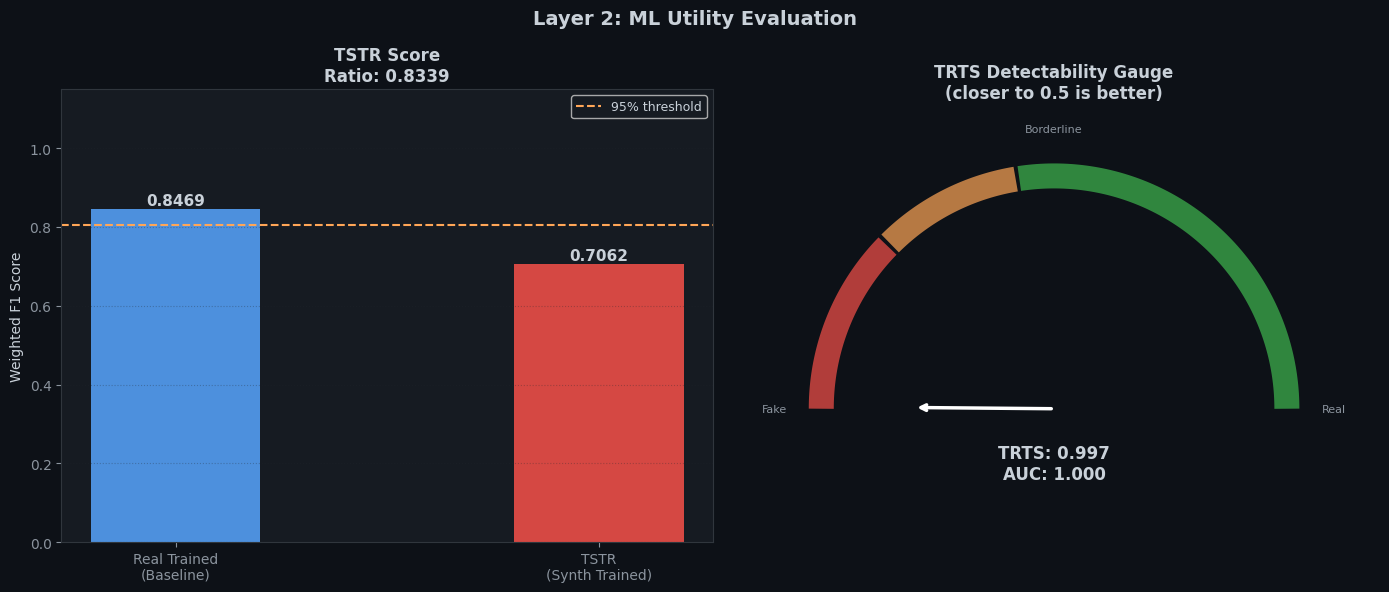

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Layer 2: ML Utility Evaluation',
             fontsize=14, fontweight='bold', color='#c9d1d9')

# TSTR comparison
ax1 = axes[0]
labels = ['Real Trained\n(Baseline)', 'TSTR\n(Synth Trained)']
scores = [f1_real_baseline, f1_tstr]
colors = [REAL_COLOR, SYNTH_COLOR]
bars   = ax1.bar(labels, scores,
                 color=colors, alpha=0.85, width=0.4)
ax1.axhline(y=0.95 * f1_real_baseline,
            color=WARN_COLOR, linestyle='--',
            linewidth=1.5, label='95% threshold')
ax1.set_ylim(0, 1.15)
ax1.set_ylabel('Weighted F1 Score')
ax1.set_title(f'TSTR Score\nRatio: {tstr_ratio:.4f}',
              fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, scores):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.4f}', ha='center',
             fontweight='bold', fontsize=11)

# TRTS gauge
ax2 = axes[1]
theta = np.linspace(0, np.pi, 200)
for start, end, color in [
    (0.0, 0.55, PASS_COLOR),
    (0.55, 0.75, WARN_COLOR),
    (0.75, 1.0,  FAIL_COLOR)
]:
    mask = (theta >= start * np.pi) & (theta <= end * np.pi)
    ax2.plot(np.cos(theta[mask]), np.sin(theta[mask]),
             linewidth=18, color=color,
             solid_capstyle='butt', alpha=0.7)

needle = trts_score * np.pi
ax2.annotate('',
    xy=(0.6 * np.cos(needle), 0.6 * np.sin(needle)),
    xytext=(0, 0),
    arrowprops=dict(arrowstyle='->',
                    color='white', lw=2.5))
ax2.text(0, -0.3,
         f'TRTS: {trts_score:.3f}\nAUC: {trts_auc:.3f}',
         ha='center', fontsize=12,
         fontweight='bold', color='#c9d1d9')
for val, label in [
    (0, 'Real'), (0.5, 'Borderline'), (1.0, 'Fake')
]:
    a = val * np.pi
    ax2.text(1.2 * np.cos(a), 1.2 * np.sin(a),
             label, ha='center', va='center',
             fontsize=8, color='#8b949e')
ax2.set_xlim(-1.4, 1.4)
ax2.set_ylim(-0.5, 1.3)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title('TRTS Detectability Gauge\n(closer to 0.5 is better)',
              fontweight='bold')

plt.tight_layout()
plt.savefig('layer2_ml_utility.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
## Layer 3: Visual Evaluation with UMAP

UMAP projects high-dimensional data into 2D while preserving
neighborhood structure. If the real and synthetic clouds overlap
heavily, the synthetic data covers the real distribution well.
If they separate cleanly, the generator is missing something.

In [10]:
print("Running UMAP dimensionality reduction...")
print("This takes about 2 to 3 minutes.")

# Use numeric features only
real_num  = real_enc[num_cols].fillna(0).values
synth_num = synth_enc[num_cols].fillna(0).values

# Scale before UMAP
scaler   = StandardScaler()
combined_arr = np.vstack([real_num, synth_num])
combined_scaled = scaler.fit_transform(combined_arr)
labels = np.array([0] * len(real_num) + [1] * len(synth_num))

reducer   = umap.UMAP(random_state=42, n_neighbors=15,
                       min_dist=0.1, n_components=2)
embedding = reducer.fit_transform(combined_scaled)

print(f"UMAP complete. Embedding shape: {embedding.shape}")

Running UMAP dimensionality reduction...
This takes about 2 to 3 minutes.
UMAP complete. Embedding shape: (6000, 2)


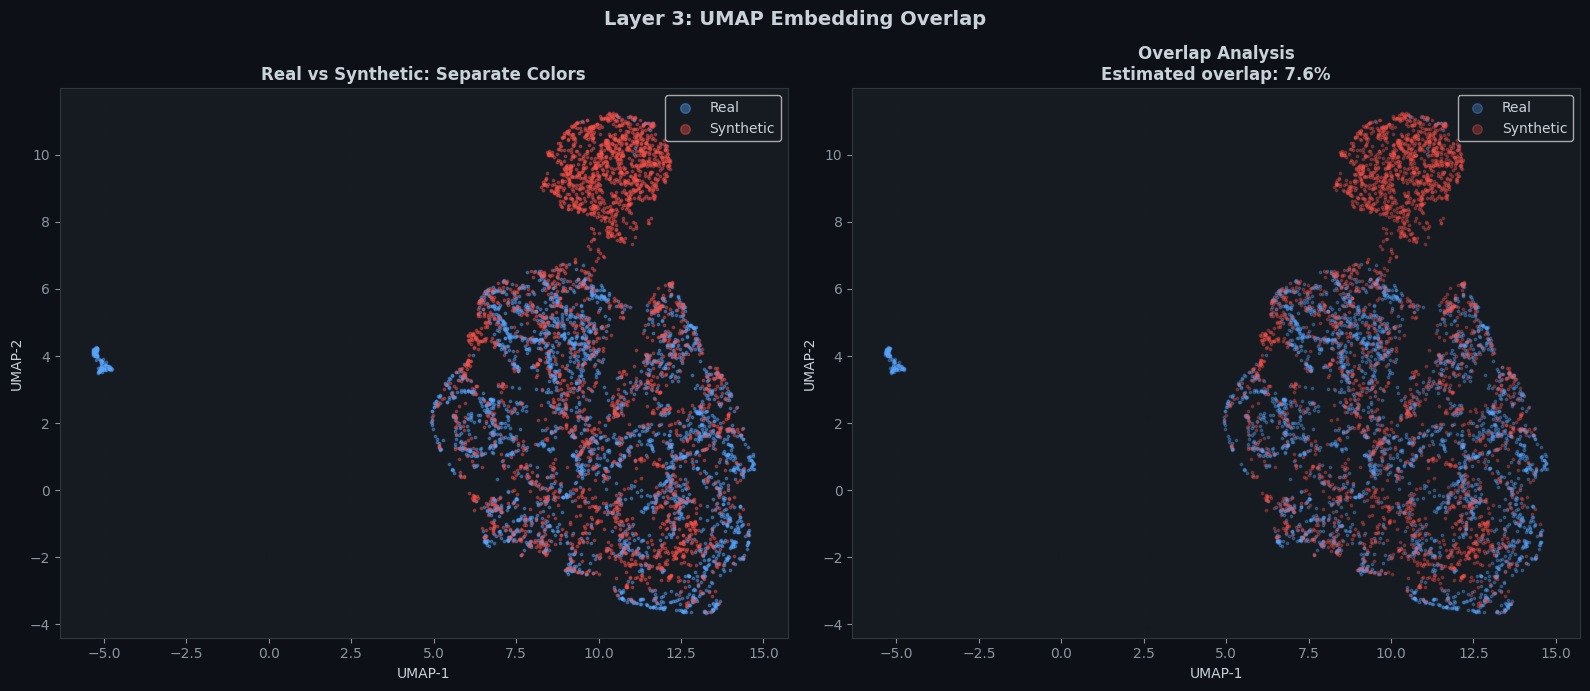

Estimated embedding overlap: 7.6%
Higher overlap = better coverage of real distribution.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Layer 3: UMAP Embedding Overlap',
             fontsize=14, fontweight='bold', color='#c9d1d9')

# Separate plots
ax1 = axes[0]
for lbl, color, name in [
    (0, REAL_COLOR,  'Real'),
    (1, SYNTH_COLOR, 'Synthetic')
]:
    mask = labels == lbl
    ax1.scatter(embedding[mask, 0], embedding[mask, 1],
                c=color, s=3, alpha=0.4, label=name)
ax1.set_title('Real vs Synthetic: Separate Colors',
              fontweight='bold')
ax1.legend(markerscale=4, fontsize=10)
ax1.set_xlabel('UMAP-1')
ax1.set_ylabel('UMAP-2')
ax1.grid(True, alpha=0.2)

# Density-style overlay
ax2 = axes[1]
mask_r = labels == 0
mask_s = labels == 1
ax2.scatter(embedding[mask_r, 0], embedding[mask_r, 1],
            c=REAL_COLOR, s=3, alpha=0.3, label='Real')
ax2.scatter(embedding[mask_s, 0], embedding[mask_s, 1],
            c=SYNTH_COLOR, s=3, alpha=0.3, label='Synthetic')

# Overlap annotation
from scipy.spatial.distance import cdist
sample_r = embedding[mask_r][:200]
sample_s = embedding[mask_s][:200]
dists    = cdist(sample_r, sample_s, metric='euclidean')
overlap  = (dists < 2.0).sum() / dists.size

ax2.set_title(f'Overlap Analysis\nEstimated overlap: {overlap*100:.1f}%',
              fontweight='bold')
ax2.legend(markerscale=4, fontsize=10)
ax2.set_xlabel('UMAP-1')
ax2.set_ylabel('UMAP-2')
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('layer3_umap.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f"Estimated embedding overlap: {overlap*100:.1f}%")
print("Higher overlap = better coverage of real distribution.")

---
## Layer 4: Privacy Audit

A membership inference attack tries to determine whether a specific
real record was used to train the generator. If the attack succeeds
at a high rate, the synthetic data is leaking information about
real individuals.

We simulate this by training a classifier to distinguish training
records from held-out records using only the synthetic data as a proxy.

In [12]:
print("Running membership inference attack simulation...")

# Split real data into training (used to fit generator)
# and holdout (never seen by generator)
real_train, real_holdout = train_test_split(
    real_enc, test_size=0.3, random_state=42)

# The attacker knows: synthetic data and some real records
# Goal: guess which real records were in the training set
# Proxy: use feature similarity to synthetic data as the signal

scaler_mia = StandardScaler()
synth_scaled  = scaler_mia.fit_transform(
    synth_enc[num_cols].fillna(0))
train_scaled  = scaler_mia.transform(
    real_train[num_cols].fillna(0))
hold_scaled   = scaler_mia.transform(
    real_holdout[num_cols].fillna(0))

# Compute min distance to any synthetic record
from scipy.spatial.distance import cdist

dist_train = cdist(
    train_scaled[:300], synth_scaled[:300]
).min(axis=1)
dist_hold  = cdist(
    hold_scaled[:300],  synth_scaled[:300]
).min(axis=1)

# If training records are closer to synthetic,
# the attack can identify them
threshold_mia = np.median(
    np.concatenate([dist_train, dist_hold]))
tp = (dist_train < threshold_mia).sum()
fp = (dist_hold  < threshold_mia).sum()
attack_acc = (tp + (len(dist_hold) - fp)) / (
    len(dist_train) + len(dist_hold))

print(f"MIA simulation accuracy: {attack_acc:.4f}")
print(f"Random baseline:         0.5000")
print(f"Difference from random:  {abs(attack_acc - 0.5):.4f}")
print()
if abs(attack_acc - 0.5) < 0.05:
    print("Privacy: GOOD. Attack accuracy close to random chance.")
elif abs(attack_acc - 0.5) < 0.10:
    print("Privacy: ACCEPTABLE. Slight memorization signal.")
else:
    print("Privacy: CONCERN. Generator may be memorizing training data.")

Running membership inference attack simulation...
MIA simulation accuracy: 0.5000
Random baseline:         0.5000
Difference from random:  0.0000

Privacy: GOOD. Attack accuracy close to random chance.


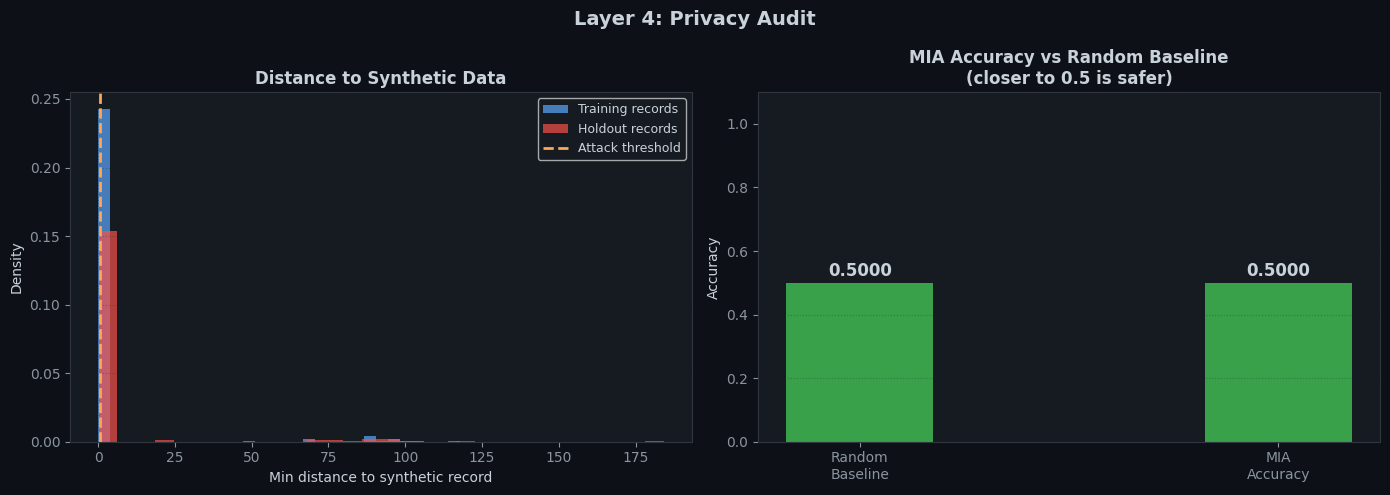

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Layer 4: Privacy Audit',
             fontsize=14, fontweight='bold', color='#c9d1d9')

# Distance distributions
ax1 = axes[0]
ax1.hist(dist_train, bins=30, color=REAL_COLOR,
         alpha=0.7, label='Training records', density=True)
ax1.hist(dist_hold,  bins=30, color=SYNTH_COLOR,
         alpha=0.7, label='Holdout records',  density=True)
ax1.axvline(x=threshold_mia, color=WARN_COLOR,
            linestyle='--', linewidth=2,
            label=f'Attack threshold')
ax1.set_title('Distance to Synthetic Data',
              fontweight='bold')
ax1.set_xlabel('Min distance to synthetic record')
ax1.set_ylabel('Density')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Attack accuracy vs random
ax2 = axes[1]
labels_bar  = ['Random\nBaseline', 'MIA\nAccuracy']
values_bar  = [0.5, attack_acc]
color_bar   = [PASS_COLOR,
               PASS_COLOR if abs(attack_acc-0.5) < 0.05
               else WARN_COLOR if abs(attack_acc-0.5) < 0.10
               else FAIL_COLOR]
bars = ax2.bar(labels_bar, values_bar,
               color=color_bar, alpha=0.85, width=0.35)
ax2.set_ylim(0, 1.1)
ax2.set_ylabel('Accuracy')
ax2.set_title('MIA Accuracy vs Random Baseline\n(closer to 0.5 is safer)',
              fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, values_bar):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{val:.4f}', ha='center',
             fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('layer4_privacy.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
## Final Report Card

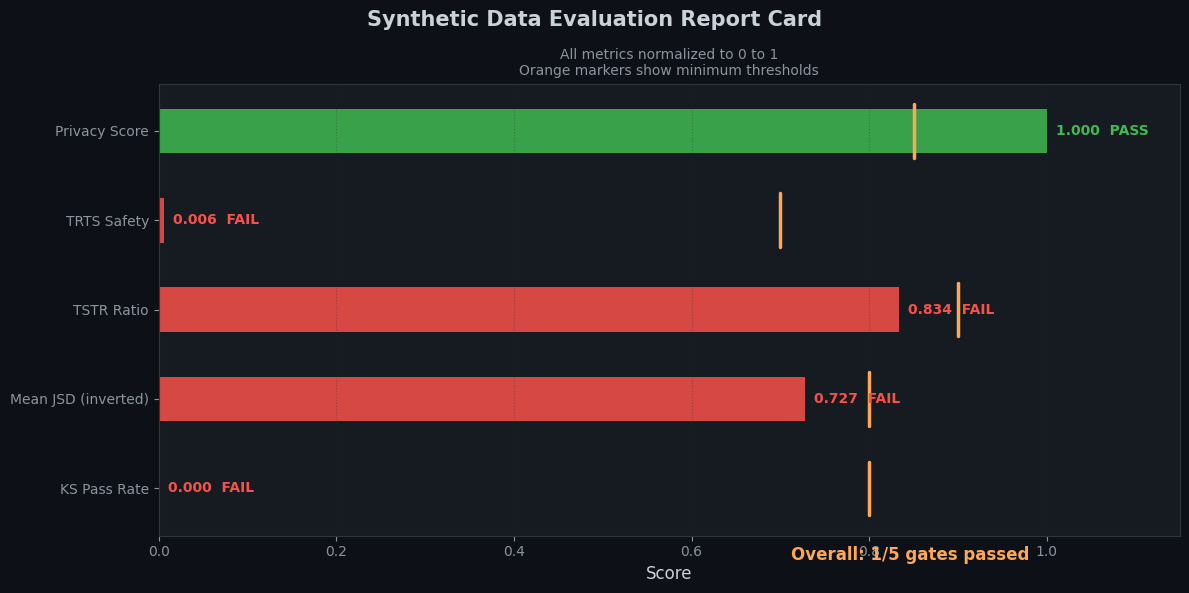

In [14]:
ks_pass_rate  = ks_df['pass'].mean()
mean_jsd      = ks_df['jsd'].mean()
privacy_score = 1 - abs(attack_acc - 0.5) * 2

metrics = [
    ('KS Pass Rate',         ks_pass_rate,  0.80),
    ('Mean JSD (inverted)',  1 - mean_jsd,  0.80),
    ('TSTR Ratio',           tstr_ratio,    0.90),
    ('TRTS Safety',          1 - (trts_score - 0.5) * 2 if trts_score > 0.5 else 1.0, 0.70),
    ('Privacy Score',        privacy_score, 0.85),
]

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Synthetic Data Evaluation Report Card',
             fontsize=15, fontweight='bold', color='#c9d1d9')

names  = [m[0] for m in metrics]
scores = [m[1] for m in metrics]
thresh = [m[2] for m in metrics]
colors = [PASS_COLOR if s >= t else FAIL_COLOR
          for s, t in zip(scores, thresh)]

bars = ax.barh(names, scores, color=colors,
               alpha=0.85, height=0.5)
for t, y in zip(thresh, range(len(names))):
    ax.plot([t, t], [y - 0.3, y + 0.3],
            color=WARN_COLOR, linewidth=2.5,
            solid_capstyle='round')

ax.set_xlim(0, 1.15)
ax.set_xlabel('Score', fontsize=12)
ax.set_title('All metrics normalized to 0 to 1\n'
             'Orange markers show minimum thresholds',
             fontsize=10, color='#8b949e')
ax.grid(True, alpha=0.3, axis='x')

for bar, score, t in zip(bars, scores, thresh):
    status = 'PASS' if score >= t else 'FAIL'
    color  = PASS_COLOR if score >= t else FAIL_COLOR
    ax.text(score + 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{score:.3f}  {status}',
            va='center', fontweight='bold',
            color=color, fontsize=10)

overall = sum(s >= t for s, t in zip(scores, thresh))
ax.text(0.98, -0.8,
        f'Overall: {overall}/{len(metrics)} gates passed',
        ha='right', fontsize=12, fontweight='bold',
        color=PASS_COLOR if overall == len(metrics) else WARN_COLOR,
        transform=ax.transData)

plt.tight_layout()
plt.savefig('final_report_card.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

---
## Summary

In [15]:
print("=" * 60)
print("  TMD-07: Complete Evaluation Suite · Summary")
print("=" * 60)
print()
print("  Layer 1: Statistical Fidelity")
print(f"    KS pass rate:       {ks_pass_rate*100:.1f}%")
print(f"    Mean JSD:           {mean_jsd:.4f}")
print()
print("  Layer 2: ML Utility")
print(f"    TSTR ratio:         {tstr_ratio:.4f}")
print(f"    TRTS accuracy:      {trts_score:.4f} (want near 0.5)")
print()
print("  Layer 3: Visual")
print(f"    UMAP overlap est:   {overlap*100:.1f}%")
print()
print("  Layer 4: Privacy")
print(f"    MIA accuracy:       {attack_acc:.4f} (want near 0.5)")
print(f"    Privacy score:      {privacy_score:.4f}")
print()
print(f"  Report card:          {overall}/{len(metrics)} gates passed")
print("=" * 60)
print()
print("  This completes the TMD notebook series.")
print()
print("  Handbook: Teaching Machines to Dream")
print("  Authors:  Aimal Khan · Hamza Raziq Khan")
print("  Peshawar, 2026")

  TMD-07: Complete Evaluation Suite · Summary

  Layer 1: Statistical Fidelity
    KS pass rate:       0.0%
    Mean JSD:           0.2727

  Layer 2: ML Utility
    TSTR ratio:         0.8339
    TRTS accuracy:      0.9972 (want near 0.5)

  Layer 3: Visual
    UMAP overlap est:   7.6%

  Layer 4: Privacy
    MIA accuracy:       0.5000 (want near 0.5)
    Privacy score:      1.0000

  Report card:          1/5 gates passed

  This completes the TMD notebook series.

  Handbook: Teaching Machines to Dream
  Authors:  Aimal Khan · Hamza Raziq Khan
  Peshawar, 2026


---

## Key Takeaways

1. No single metric is sufficient. Run all four layers.
2. Statistical similarity does not guarantee ML utility. A dataset can pass KS tests and still fail TSTR.
3. TRTS close to 0.5 means your synthetic data is indistinguishable from real. That is the goal.
4. UMAP gives you a visual intuition that numbers alone cannot. Use it to spot distribution gaps.
5. Privacy matters. An MIA accuracy well above 0.5 means the generator memorized training records.
6. The report card is your final answer. If a gate fails, fix the generator before using the data.

### The Complete TMD Series

| Notebook | Topic |
|----------|-------|
| TMD-01 | Tabular Data Quickstart |
| TMD-02 | CTGAN for Fraud Detection |
| TMD-03 | Synthetic Text with LLMs |
| TMD-04 | Image Augmentation Pipeline |
| TMD-05 | Diffusion Model Generation |
| TMD-06 | Pipeline Quality Gates |
| TMD-07 | Complete Evaluation Suite |

All notebooks are companion resources to the handbook
**Teaching Machines to Dream: A Practical Engineer's Handbook on Synthetic Data**.

---

*Part of the Teaching Machines to Dream handbook series.*  
*Aimal Khan · Hamza Raziq Khan · Peshawar, 2026*